In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal

In [22]:
class EqnState(TypedDict):
    a:int
    b:int
    c:int
    equation: str
    discriminant:float
    result: str

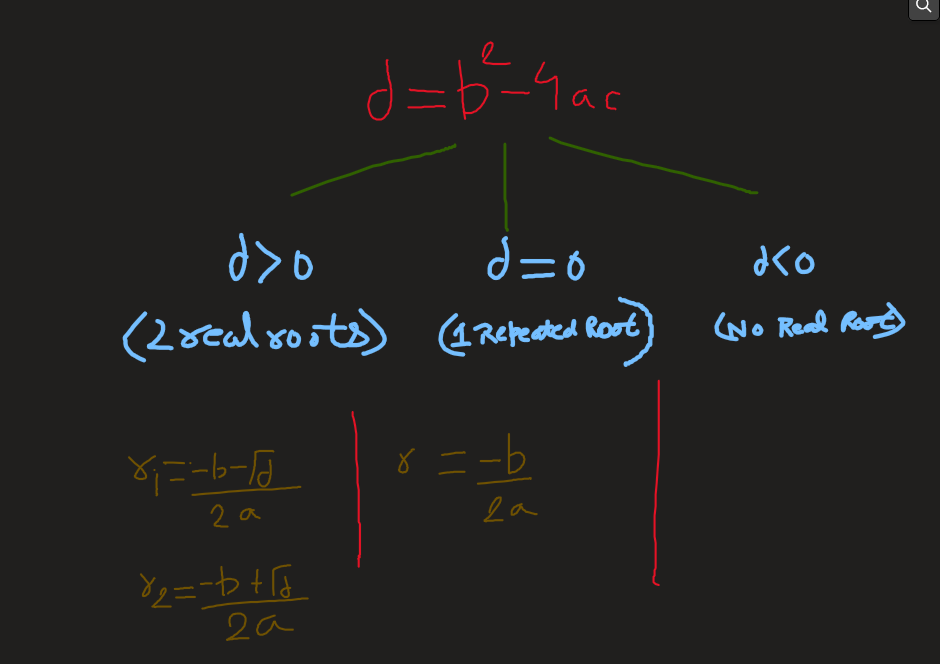

In [23]:
def show_eqn(state:EqnState):
    equation = f'{state["a"]}x\u00b2 + {state["b"]}x + {state["c"]}'
    return {'equation':equation}

def calc_discm(state: EqnState):
    discriminant = state["b"]**2 - (4*state["a"]*state["c"])
    return {'discriminant': discriminant}

def real_roots(state: EqnState):
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])
    result = f'The roots are {root1} and {root2}'
    return {'result': result}

def repeated_roots(state: EqnState):
    root = (-state["b"])/(2*state["a"])
    result = f'Only repeating root is {root}'
    return {'result': result}

def no_real_roots(state: EqnState):
    result = f'No real roots'
    return {'result': result}

def check_condition(state: EqnState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [24]:
graph = StateGraph(EqnState)

graph.add_node('show_equation', show_eqn)
graph.add_node('calculate_discriminant', calc_discm)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

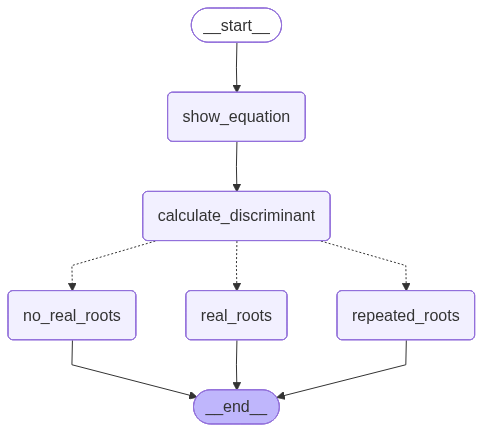

In [25]:
workflow

In [26]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}
workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x² + 4x + 2',
 'discriminant': 0,
 'result': 'Only repeating root is -1.0'}